EDA for stock market data analysis

In [3]:
import os
import sys
import talib
import pandas as pd
import yfinance as yf
import plotly as px
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime , timedelta

#import plotly.express as px



Reading the raw data

In [5]:
apple = pd.read_csv(r"C:\Users\hp\Downloads\Data-20241212T111214Z-001\Data\yfinance_data\yfinance_data\AAPL_historical_data.csv")
apple.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0.0
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086898,105728000,0.0,0.0
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089049,86441600,0.0,0.0
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091630,73449600,0.0,0.0


In [7]:

print("\nMissing Values:")
apple.isnull().sum()    #checking for missing value


Missing Values:


Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [9]:
def validate_and_prepare_stock_data(apple):
    if 'date' in apple.columns:
        try:
            apple['date'] = pd.to_datetime(apple['date'], infer_datetime_format=True)
        except pd.errors.ParserError:
            print("Warning: Could not parse 'date' column to datetime format. Check format.")
        apple.set_index('date', inplace=True)

    required_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    for column in required_columns:
        if column not in apple.columns:
            raise ValueError(f"Missing required column: {column}")

    print("\nBasic Statistics:")
    print(apple.describe())

    print("\nDataFrame Structure:")
    print(apple.info())

# calling the function
validate_and_prepare_stock_data(apple)


Basic Statistics:
               Open          High           Low         Close     Adj Close  \
count  10998.000000  10998.000000  10998.000000  10998.000000  10998.000000   
mean      22.299160     22.539055     22.068367     22.312754     21.494496   
std       46.003685     46.496031     45.540929     46.037660     45.561916   
min        0.049665      0.049665      0.049107      0.049107      0.037857   
25%        0.299107      0.303710      0.290179      0.298549      0.241840   
50%        0.531250      0.537946      0.522321      0.531250      0.432079   
75%       20.204196     20.389554     19.998036     20.196160     17.253029   
max      236.479996    237.229996    233.089996    234.820007    234.548523   

             Volume     Dividends  Stock Splits  
count  1.099800e+04  10998.000000  10998.000000  
mean   3.180806e+08      0.000752      0.001546  
std    3.354523e+08      0.011753      0.083663  
min    0.000000e+00      0.000000      0.000000  
25%    1.132545e+08

In [11]:
def calculate_indicators(df):
    
    # Calculate 20-day Simple Moving Average (SMA) and Exponential Moving Average (EMA)
    df['SMA20'] = talib.SMA(df['Close'], timeperiod=20)
    df['EMA'] = talib.EMA(df['Close'], timeperiod=20)

    # Calculate RSI (Relative Strength Index)
    df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

    # Calculate MACD (Moving Average Convergence Divergence)
    macd, macdsignal, macdhist = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
    df['MACD'] = macd
    df['MACD_Signal'] = macdsignal
    df['MACD_Hist'] = macdhist

    # Calculate daily returns
    df['Return'] = df['Close'].pct_change()

    # Calculate rolling volatility (21-day rolling standard deviation of returns)
    df['Volatility'] = df['Return'].rolling(window=21).std()

    # Filter the DataFrame to include only data from 2020
    ##apple_2020 = df.loc['2020-01-01':'2020-12-31']
    
    return df



# Example usage:
df_2020 = calculate_indicators(apple)
print(df_2020.head())

         Date      Open      High       Low     Close  Adj Close     Volume  \
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600   
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800   
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000   
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600   
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600   

   Dividends  Stock Splits  SMA20  EMA  RSI  MACD  MACD_Signal  MACD_Hist  \
0        0.0           0.0    NaN  NaN  NaN   NaN          NaN        NaN   
1        0.0           0.0    NaN  NaN  NaN   NaN          NaN        NaN   
2        0.0           0.0    NaN  NaN  NaN   NaN          NaN        NaN   
3        0.0           0.0    NaN  NaN  NaN   NaN          NaN        NaN   
4        0.0           0.0    NaN  NaN  NaN   NaN          NaN        NaN   

     Return  Volatility  
0       NaN         NaN  
1 -0.05217

## visualization

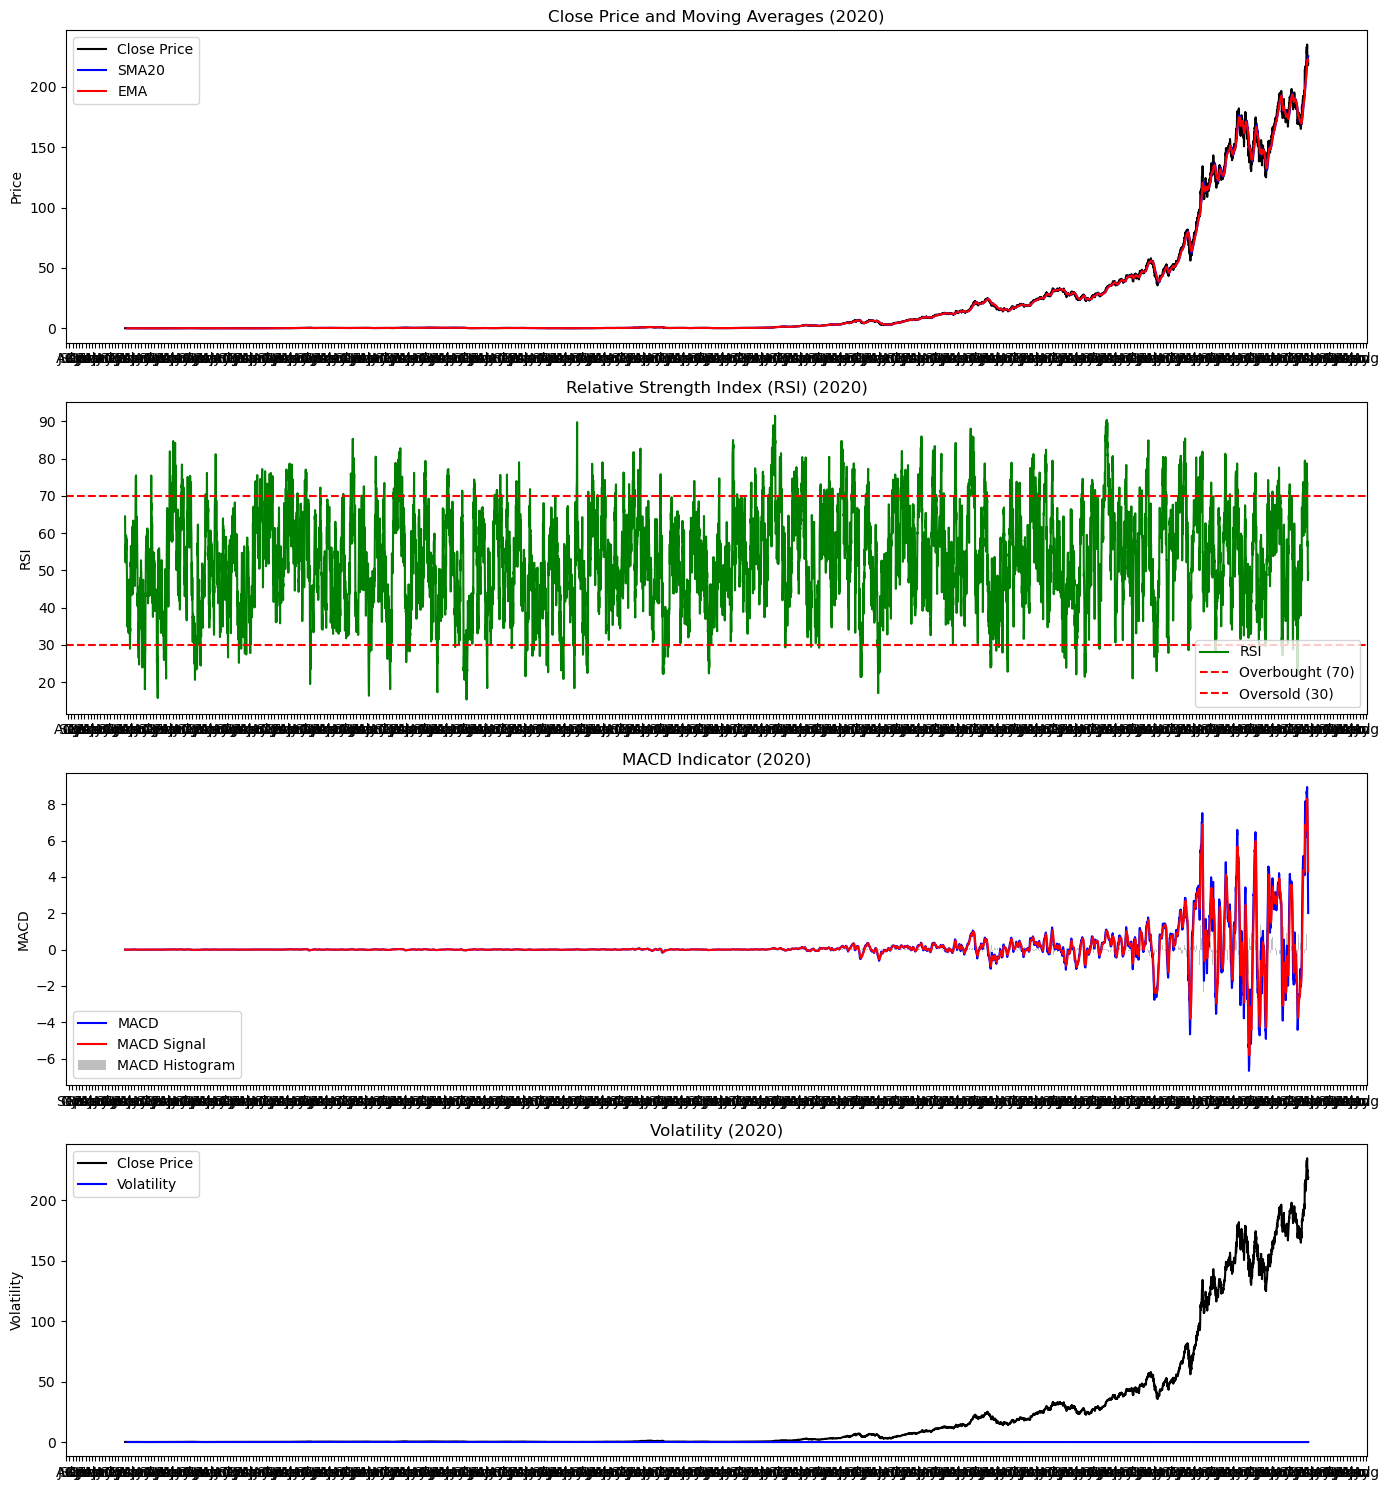

In [13]:

def plot_indicators(df, title_prefix="2020"):
    
    plt.figure(figsize=(14, 15))

    # Plot Close Price and Moving Averages
    plt.subplot(4, 1, 1)
    plt.plot(df['Close'], label='Close Price', color='black')
    plt.plot(df['SMA20'], label='SMA20', color='blue')
    plt.plot(df['EMA'], label='EMA', color='red')
    plt.title(f'Close Price and Moving Averages ({title_prefix})')
    plt.ylabel('Price')
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Plot RSI
    plt.subplot(4, 1, 2)
    plt.plot(df['RSI'], label='RSI', color='green')
    plt.title(f'Relative Strength Index (RSI) ({title_prefix})')
    plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
    plt.axhline(30, color='red', linestyle='--', label='Oversold (30)')
    plt.ylabel('RSI')
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Plot MACD
    plt.subplot(4, 1, 3)
    plt.plot(df['MACD'], label='MACD', color='blue')
    plt.plot(df['MACD_Signal'], label='MACD Signal', color='red')
    plt.bar(df.index, df['MACD_Hist'], label='MACD Histogram', color='grey', alpha=0.5)
    plt.ylabel('MACD')
    plt.title(f'MACD Indicator ({title_prefix})')
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Plot Close Price and Volatility
    plt.subplot(4, 1, 4)
    plt.plot(df['Close'], label='Close Price', color='black')
    plt.plot(df['Volatility'], label='Volatility', color='blue')
    plt.title(f'Volatility ({title_prefix})')
    plt.ylabel('Volatility')
    plt.legend()
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()

# Example usage:
plot_indicators(apple)


###### EDA FOR AMAZON STOCK MARKET DATA

In [16]:
amz = pd.read_csv(r"C:\Users\hp\Downloads\Data-20241212T111214Z-001\Data\yfinance_data\yfinance_data\AMZN_historical_data.csv")
print(amz.head())

print("\nMissing Values:")
amz.isnull().sum()    #checking for missing value

         Date      Open      High       Low     Close  Adj Close      Volume  \
0  1997-05-15  0.121875  0.125000  0.096354  0.097917   0.097917  1443120000   
1  1997-05-16  0.098438  0.098958  0.085417  0.086458   0.086458   294000000   
2  1997-05-19  0.088021  0.088542  0.081250  0.085417   0.085417   122136000   
3  1997-05-20  0.086458  0.087500  0.081771  0.081771   0.081771   109344000   
4  1997-05-21  0.081771  0.082292  0.068750  0.071354   0.071354   377064000   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  

Missing Values:


Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


Basic Statistics:
              Open         High          Low        Close    Adj Close  \
count  6846.000000  6846.000000  6846.000000  6846.000000  6846.000000   
mean     37.360464    37.801009    36.882561    37.351096    37.351096   
std      53.756955    54.366449    53.087051    53.729913    53.729913   
min       0.070313     0.072396     0.065625     0.069792     0.069792   
25%       2.070125     2.120625     2.040156     2.076750     2.076750   
50%       8.574500     8.666750     8.466500     8.591500     8.591500   
75%      50.453876    50.723249    50.059875    50.426500    50.426500   
max     200.089996   201.199997   199.050003   200.000000   200.000000   

             Volume  Dividends  Stock Splits  
count  6.846000e+03     6846.0   6846.000000  
mean   1.380713e+08        0.0      0.003944  
std    1.382346e+08        0.0      0.246789  
min    9.744000e+06        0.0      0.000000  
25%    6.505442e+07        0.0      0.000000  
50%    1.020650e+08        0.0  

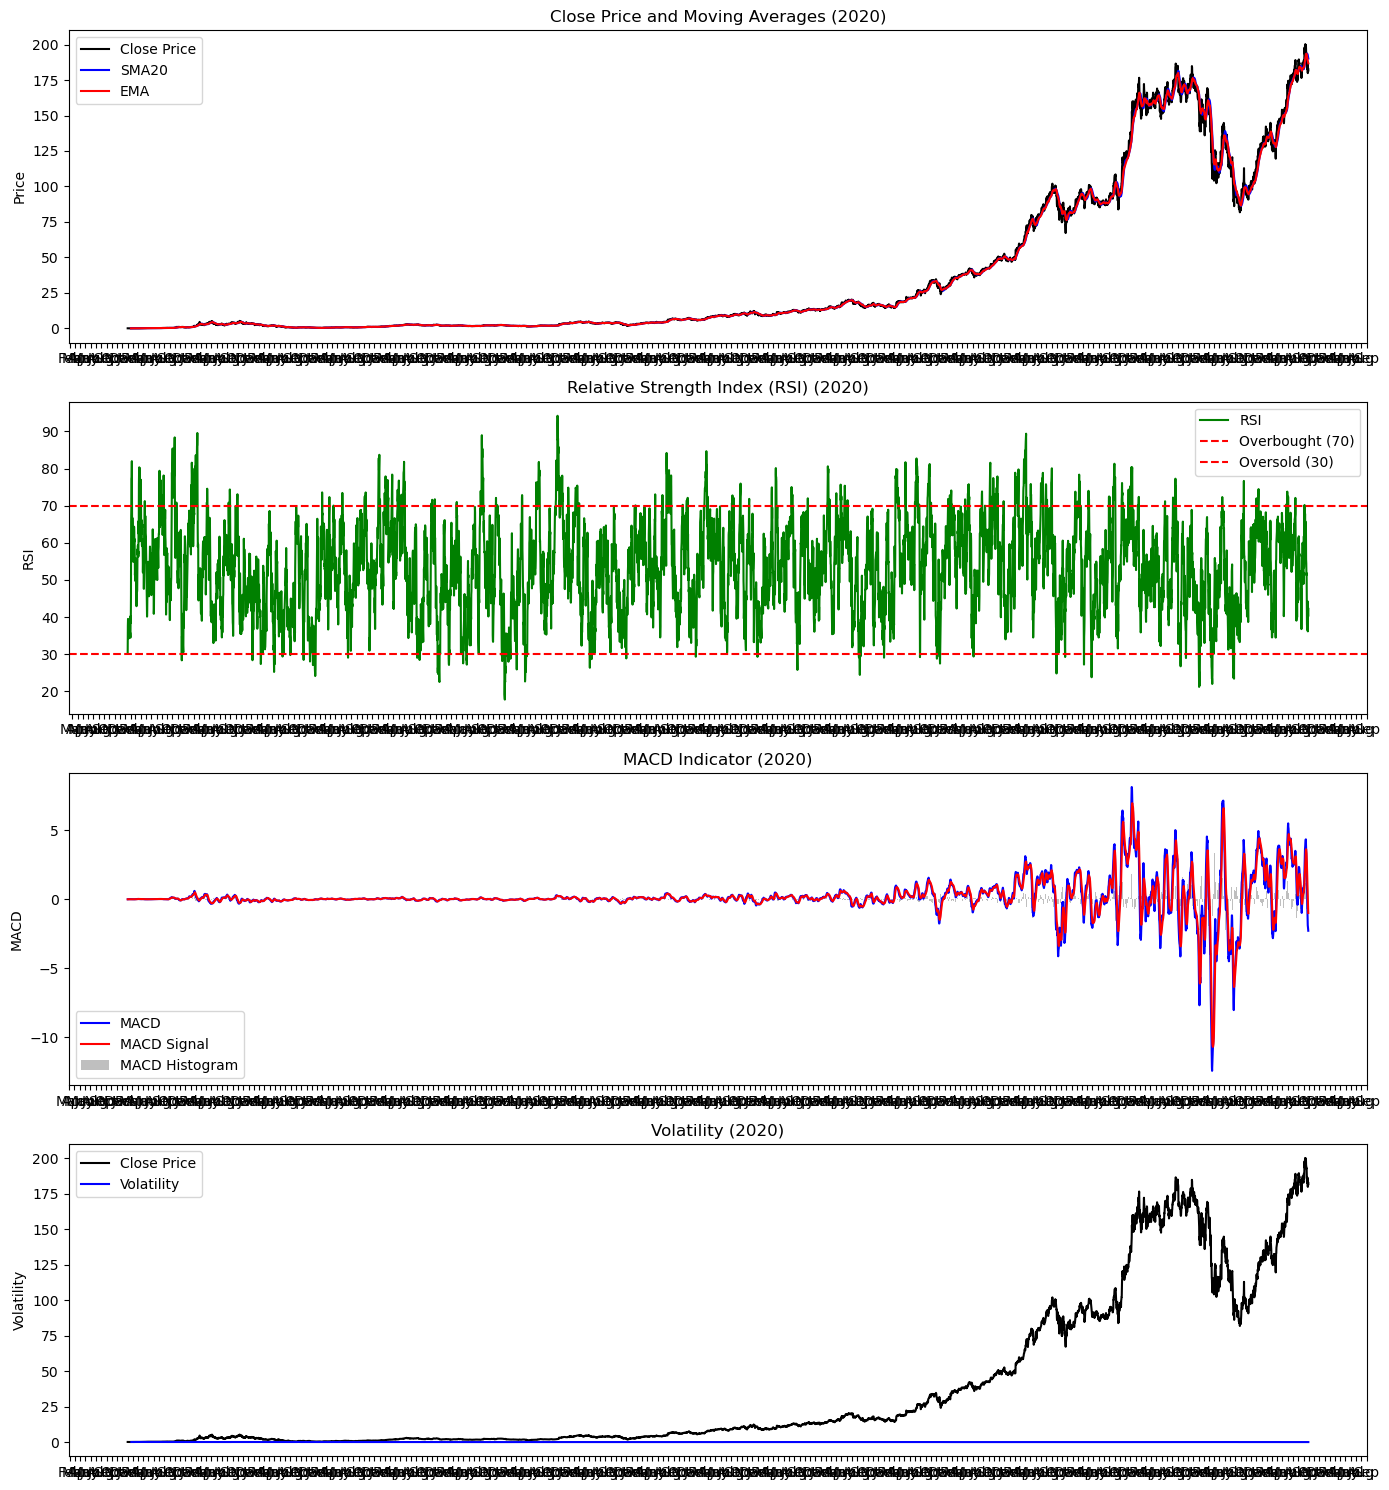

In [18]:

# calling the function
validate_and_prepare_stock_data(amz)

df1_2020 = calculate_indicators(amz)
print(df1_2020.head())

plot_indicators(amz)

EDA FOR GOOGLE STOCK MARKET DATA

In [20]:
goog = pd.read_csv(r"C:\Users\hp\Downloads\Data-20241212T111214Z-001\Data\yfinance_data\yfinance_data\GOOG_historical_data.csv")
print(goog.head())

print("\nMissing Values:")
goog.isnull().sum()    #checking for missing value

         Date      Open      High       Low     Close  Adj Close     Volume  \
0  2004-08-19  2.490664  2.591785  2.390042  2.499133   2.496292  897427216   
1  2004-08-20  2.515820  2.716817  2.503118  2.697639   2.694573  458857488   
2  2004-08-23  2.758411  2.826406  2.716070  2.724787   2.721690  366857939   
3  2004-08-24  2.770615  2.779581  2.579581  2.611960   2.608991  306396159   
4  2004-08-25  2.614201  2.689918  2.587302  2.640104   2.637103  184645512   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  

Missing Values:


Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


Basic Statistics:
              Open         High          Low        Close    Adj Close  \
count  5020.000000  5020.000000  5020.000000  5020.000000  5020.000000   
mean     45.251315    45.728793    44.800587    45.274515    45.224493   
std      43.338635    43.818298    42.918167    43.377299    43.332534   
min       2.470490     2.534002     2.390042     2.490913     2.488082   
25%      13.034705    13.145415    12.881592    13.032090    13.017277   
50%      26.982210    27.194902    26.791387    27.005927    26.975230   
75%      60.215126    60.758375    59.811811    60.280252    60.211734   
max     191.750000   193.309998   190.619995   192.660004   192.660004   

             Volume    Dividends  Stock Splits  
count  5.020000e+03  5020.000000   5020.000000  
mean   1.157539e+08     0.000040      0.004583  
std    1.497936e+08     0.002823      0.284034  
min    1.584340e+05     0.000000      0.000000  
25%    2.733950e+07     0.000000      0.000000  
50%    5.585480e+07 

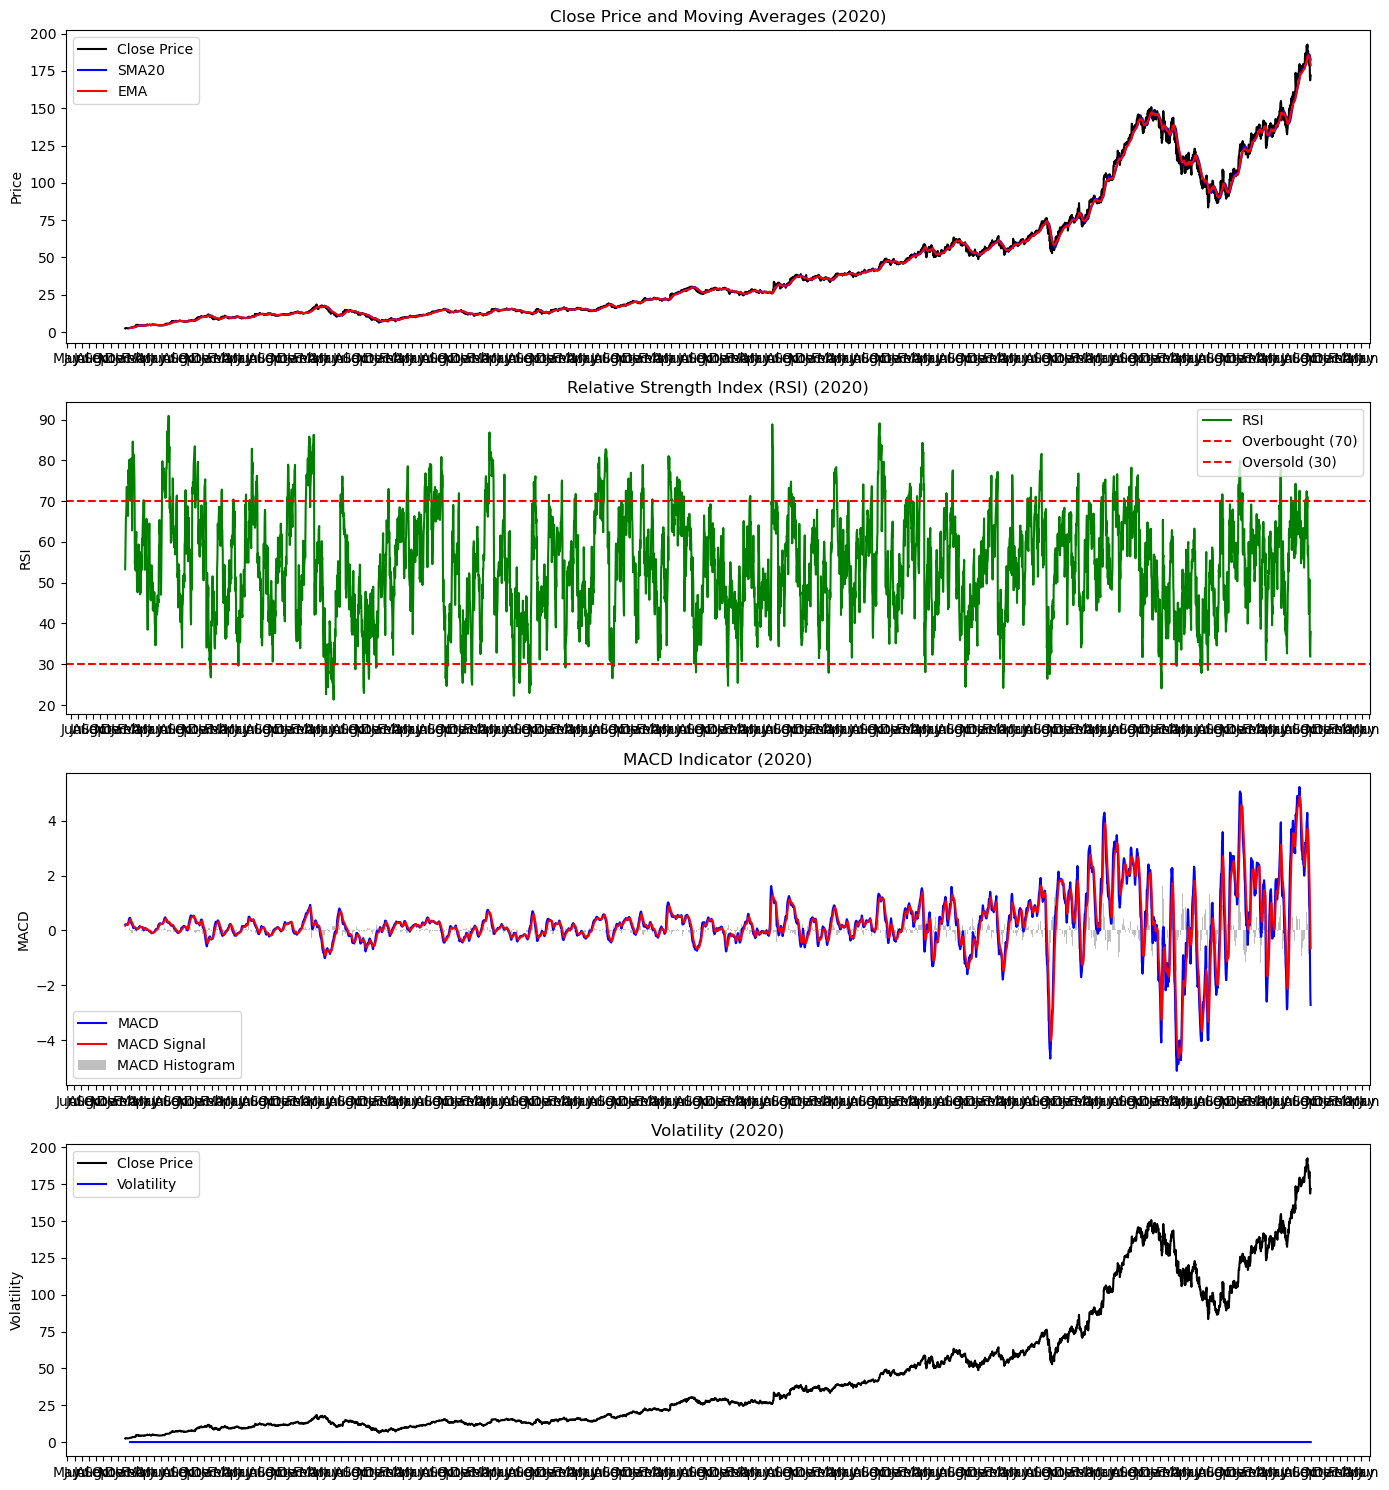

In [22]:

# calling the function
validate_and_prepare_stock_data(goog)

df2_2020 = calculate_indicators(goog)
print(df2_2020.head())

plot_indicators(goog)

EDA   FOR META STACK MARKET DATA